# XRD Diffusion Model Validation - Modular Version

This notebook provides a clean, modular interface to the XRD diffusion validation suite.
All complex functionality has been extracted into separate modules for easier debugging and maintenance.

## Quick Start

1. **Setup & Data Loading** - Load data and models
2. **Comprehensive Validation** - Run all validation tests
3. **Individual Tests** - Run specific validation components
4. **Interactive Exploration** - Explore model behavior interactively
5. **Results & Reporting** - Generate and save reports

## 1. Setup & Imports

In [15]:
# Standard imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import our modular validation suite
from validation import ValidationSuite
from validation.utils import set_random_seeds

# Set random seeds for reproducibility
set_random_seeds(42)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✓ Validation suite imported successfully")
print(f"✓ Using PyTorch version: {torch.__version__}")
print(f"✓ Device available: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

✓ Validation suite imported successfully
✓ Using PyTorch version: 2.5.1+cu121
✓ Device available: CUDA


## 2. Initialize Validation Suite

In [16]:
# Initialize the validation suite
suite = ValidationSuite(device='cuda')

print("✓ Validation suite initialized")
print(f"   Device: {suite.device}")

✓ Validation suite initialized
   Device: cuda


## 3. Load Data

In [17]:
# Load XRD dataset
dataset_path = "data/xrd_dataset_labeled_dtw_window.pt"
data_splits = suite.load_data(dataset_path)

print("✓ Data loaded successfully")
print(f"   Train samples: {len(data_splits['train']['synth'])}")
print(f"   Validation samples: {len(data_splits['val']['synth'])}")
print(f"   Test samples: {len(data_splits['test']['synth'])}")

Loading XRD dataset from data/xrd_dataset_labeled_dtw_window.pt...
Dataset loaded:
  Synthetic XRD shape: torch.Size([13325, 4500])
  Real XRD shape: torch.Size([13325, 4500])
  DTW distances shape: torch.Size([13325])
  DTW distance range: [0.358, 100.000]

Dataset splits:
  Train: 9327 samples
  Validation: 1998 samples
  Test: 2000 samples
✓ Data loaded successfully
   Train samples: 9327
   Validation samples: 1998
   Test samples: 2000


## 4. Load Model

In [18]:
# Load trained diffusion model
model_path = "diffusion/models/xrd_diffusion/best_model.pth"
model, diffusion = suite.load_model(model_path)

print("✓ Model loaded successfully")
print(f"   Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Diffusion timesteps: {diffusion.num_timesteps}")

Loading trained diffusion model...
✓ Loaded model from diffusion/models/xrd_diffusion/best_model.pth
  Trained for 98 epochs
  Best validation loss: 0.058386

Model parameters: 237,105
Diffusion timesteps: 1000
Using device: cuda
PyTorch version: 2.5.1+cu121
✓ Model loaded successfully
   Model parameters: 237,105
   Diffusion timesteps: 1000


## 5. Quick Validation (Recommended)

Run all validation tests with a single command:

In [19]:
# Run comprehensive validation suite
print("Running comprehensive validation suite...")
print("This may take a few minutes...\n")

validation_results = suite.run_all_tests(subset_size=50)

print("\n✓ Validation complete!")

Running comprehensive validation suite...
This may take a few minutes...

Running Comprehensive Validation Suite...

1. Testing Model Stochasticity...
Testing model stochasticity...
Input shape: torch.Size([1, 1, 4500]), DTW shape: torch.Size([1, 1]), t shape: torch.Size([1])

Deterministic mode:
  Average std across runs: 0.00000000
  Max absolute difference: 0.00000000

Stochastic mode:
  Average std across runs: 0.00106339
  Max absolute difference: 0.39142293

Stochasticity ratio: 3651839.00
   ✓ Deterministic std: 0.00000000
   ✓ Stochastic std: 0.00106339
   ✓ Ratio: 3651839.00 (PASS)

2. Testing Timestep Effects...
Analyzing timesteps - Input shape: torch.Size([1, 1, 4500]), DTW shape: torch.Size([1, 1])


Testing timesteps: 100%|██████████| 8/8 [00:00<00:00, 65.56it/s]


   ✓ Timestep-reconstruction error correlation: 1.000 (PASS)

3. Testing DTW Conditioning...


Testing DTW values: 100%|██████████| 11/11 [00:00<00:00, 77.35it/s]


   ✓ DTW conditioning effect std: 0.000000 (FAIL)
   ✓ DTW conditioning range: 0.000000

4. Testing Real-world Similarity...


Evaluating test set: 100%|██████████| 4/4 [00:01<00:00,  2.92it/s]

   ✓ Mean similarity to real: 0.926 (PASS)
   ✓ High similarity fraction: 0.980 (PASS)

5. Testing Model Stability...
   ✓ Model stability: PASS

VALIDATION SUMMARY
Tests passed: 4/5 (80.0%)
  stochasticity       : ✓ PASS
  timestep_effects    : ✓ PASS
  dtw_conditioning    : ✗ FAIL
  real_world_similarity: ✓ PASS
  stability           : ✓ PASS

OVERALL RESULT: ✗ SOME TESTS FAILED

✓ Validation complete!


## 6. Generate and Display Report

In [20]:
# Display comprehensive validation report
suite.print_report(validation_results)

XRD DIFFUSION MODEL VALIDATION SUMMARY REPORT

🎯 KEY QUESTIONS ANSWERED:
--------------------------------------------------

1. IS THE MODEL STOCHASTIC?
   ✅ YES - The model exhibits clear stochastic behavior
   📊 Stochastic mode is 3651839.0x more variable than deterministic
   🔧 Controllable via model.set_stochastic_mode() and model.train()/eval()
   💡 Stochastic features: dropout, stochastic depth, and variational components

2. HOW DOES CHANGING TIMESTEP AFFECT THE MODEL?
   ✅ PROGRESSIVE EFFECTS - Timesteps systematically control augmentation strength
   📈 Correlation with reconstruction error: 1.000
   🔄 Higher timesteps → More noise → Stronger augmentation
   🧬 Includes physics-based peak broadening (Scherrer equation)
   🎛️  t=0: Direct transformation, t>0: Diffusion with increasing noise

3. HOW DOES DTW DISTANCE CHANGE THE MODEL?
   ⚠️  LIMITED EFFECT - DTW conditioning may not be working properly

4. IS THIS AUGMENTATION SIMILAR TO REAL-WORLD DATA?
   ✅ REALISTIC AUGMENTATIO

## 7. Individual Test Components

You can also run individual validation components for detailed analysis:

### 7.1 Stochasticity Analysis

Testing model stochasticity...
Input shape: torch.Size([1, 1, 4500]), DTW shape: torch.Size([1, 1]), t shape: torch.Size([1])

Deterministic mode:
  Average std across runs: 0.00000000
  Max absolute difference: 0.00000000

Stochastic mode:
  Average std across runs: 0.00125016
  Max absolute difference: 0.45949233

Stochasticity ratio: 1798595.75


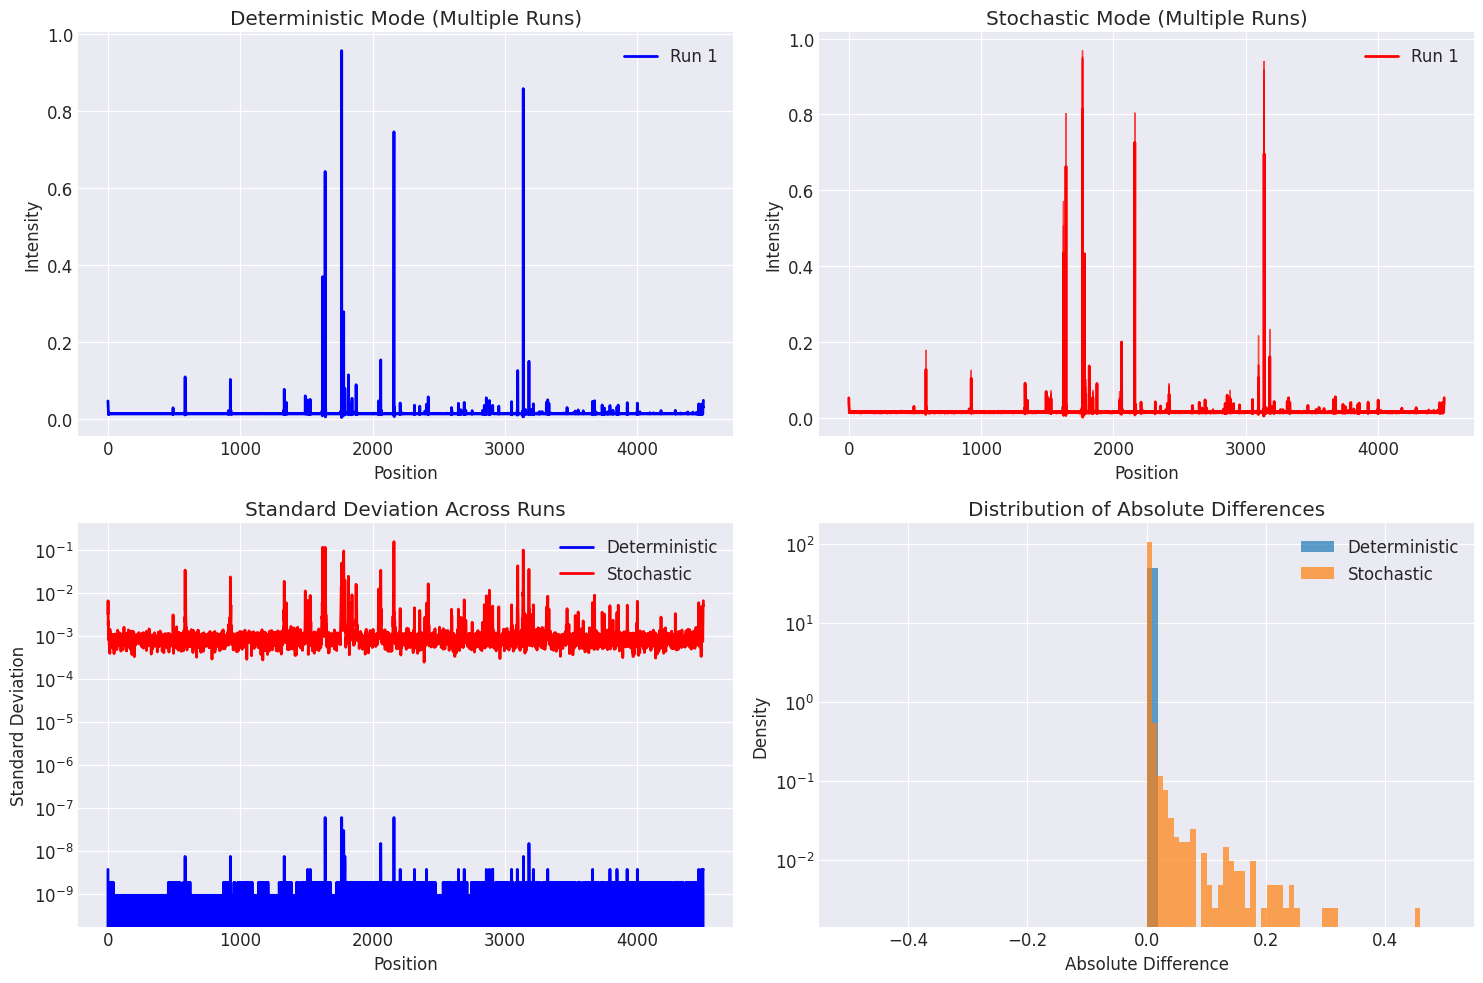

✓ Stochasticity analysis complete


In [21]:
# Individual stochasticity test
from validation.tests.stochasticity import test_model_stochasticity, generate_stochastic_variations
from validation.visualization.plotting import plot_stochasticity_analysis, plot_stochastic_variations

# Test stochasticity
test_synth = data_splits['test']['synth']
test_dtw = data_splits['test']['dtw']

det_outputs, sto_outputs = test_model_stochasticity(model, test_synth[0], test_dtw[0], n_runs=10)

# Plot results
fig = plot_stochasticity_analysis(det_outputs, sto_outputs)
plt.show()

print("✓ Stochasticity analysis complete")

### 7.2 Timestep Effects Analysis

Analyzing timesteps - Input shape: torch.Size([1, 1, 4500]), DTW shape: torch.Size([1, 1])


Testing timesteps: 100%|██████████| 8/8 [00:00<00:00, 72.18it/s]


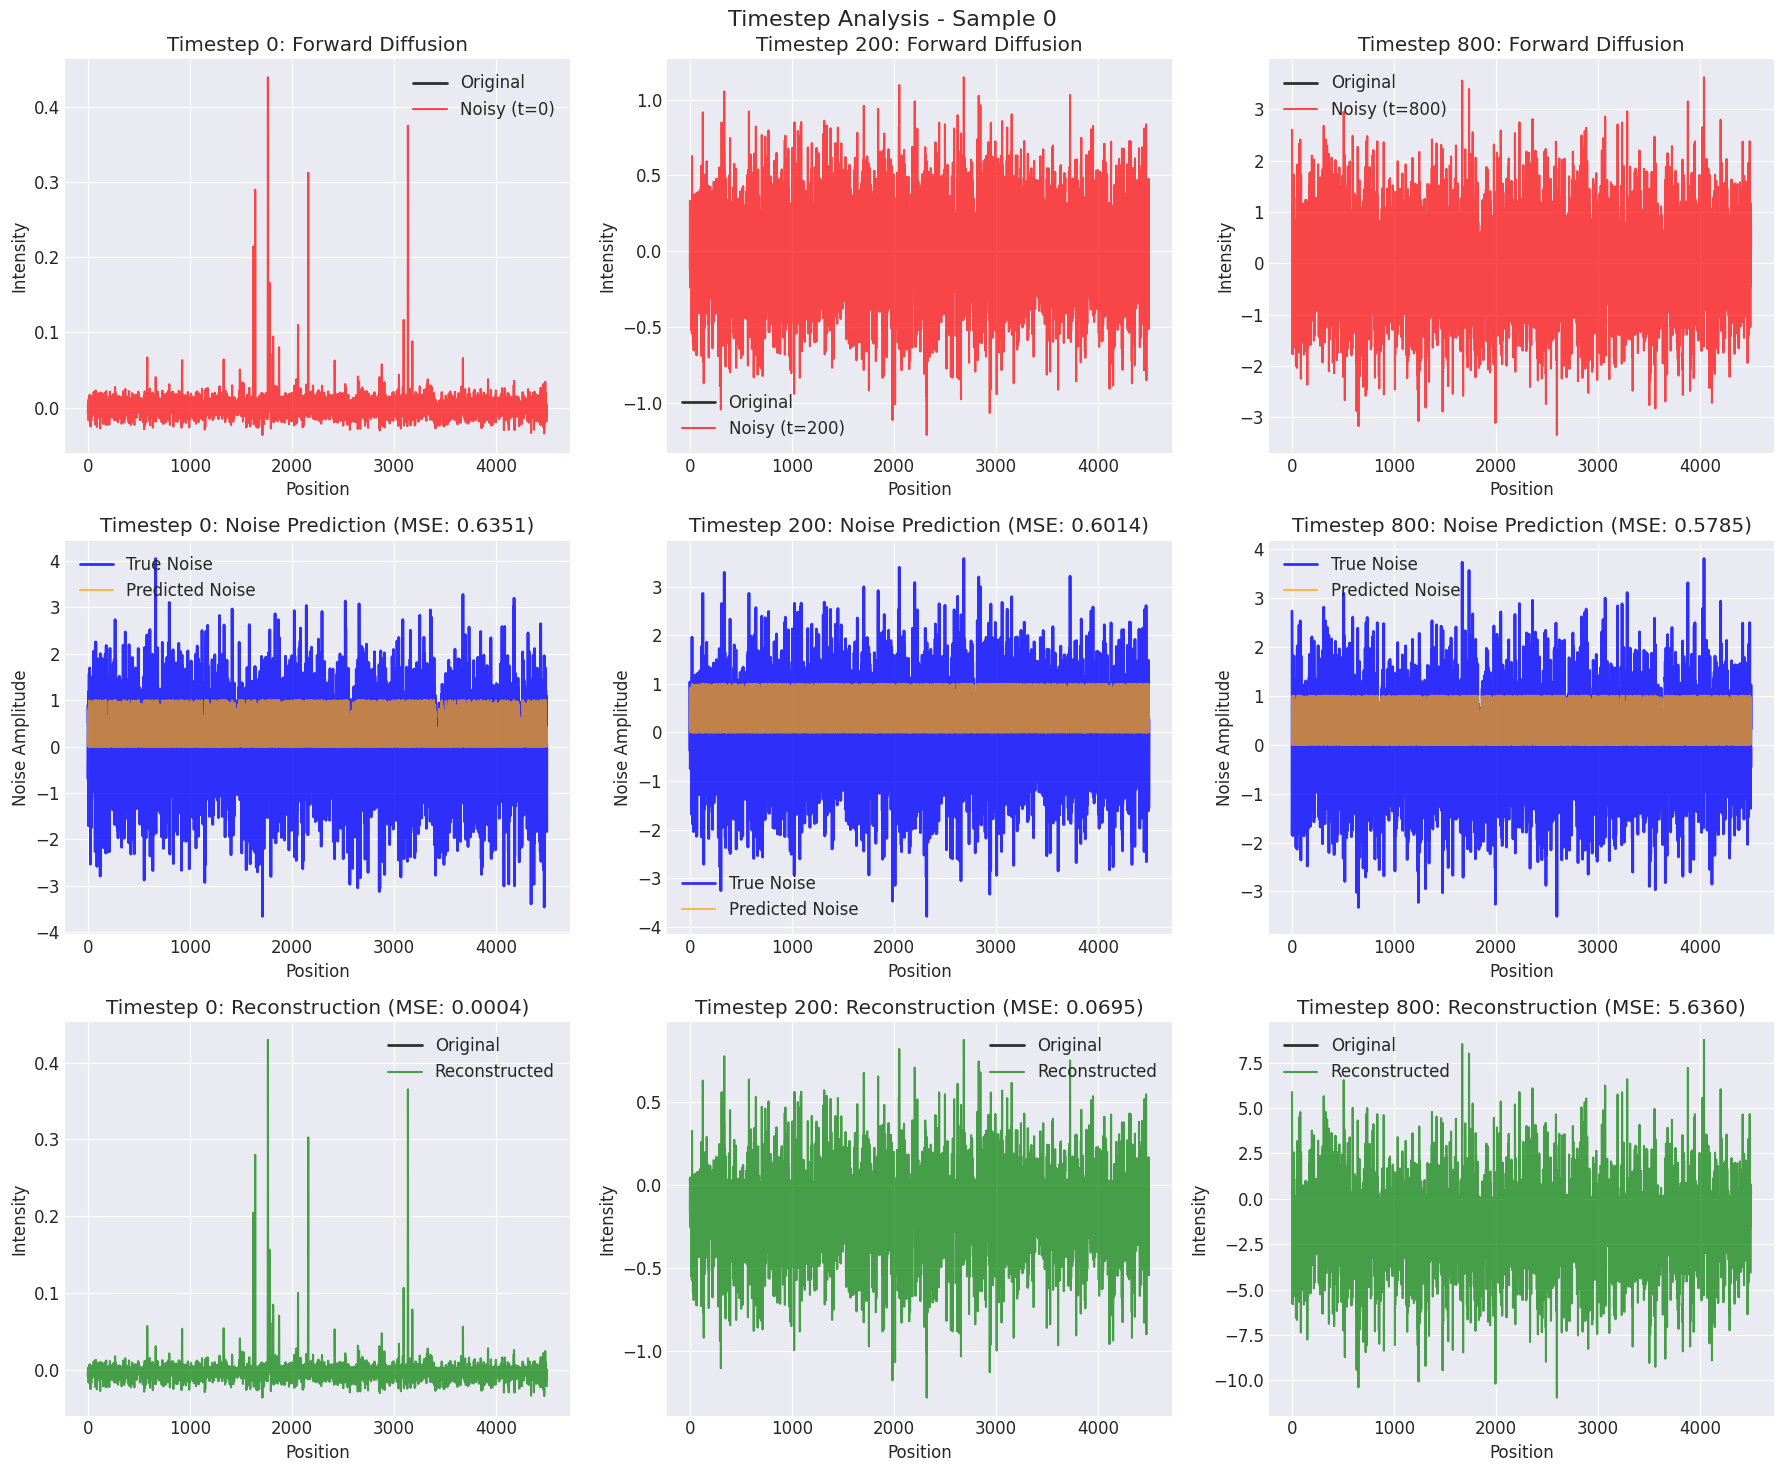

Testing progressive augmentation - Input shape: torch.Size([1, 1, 4500])


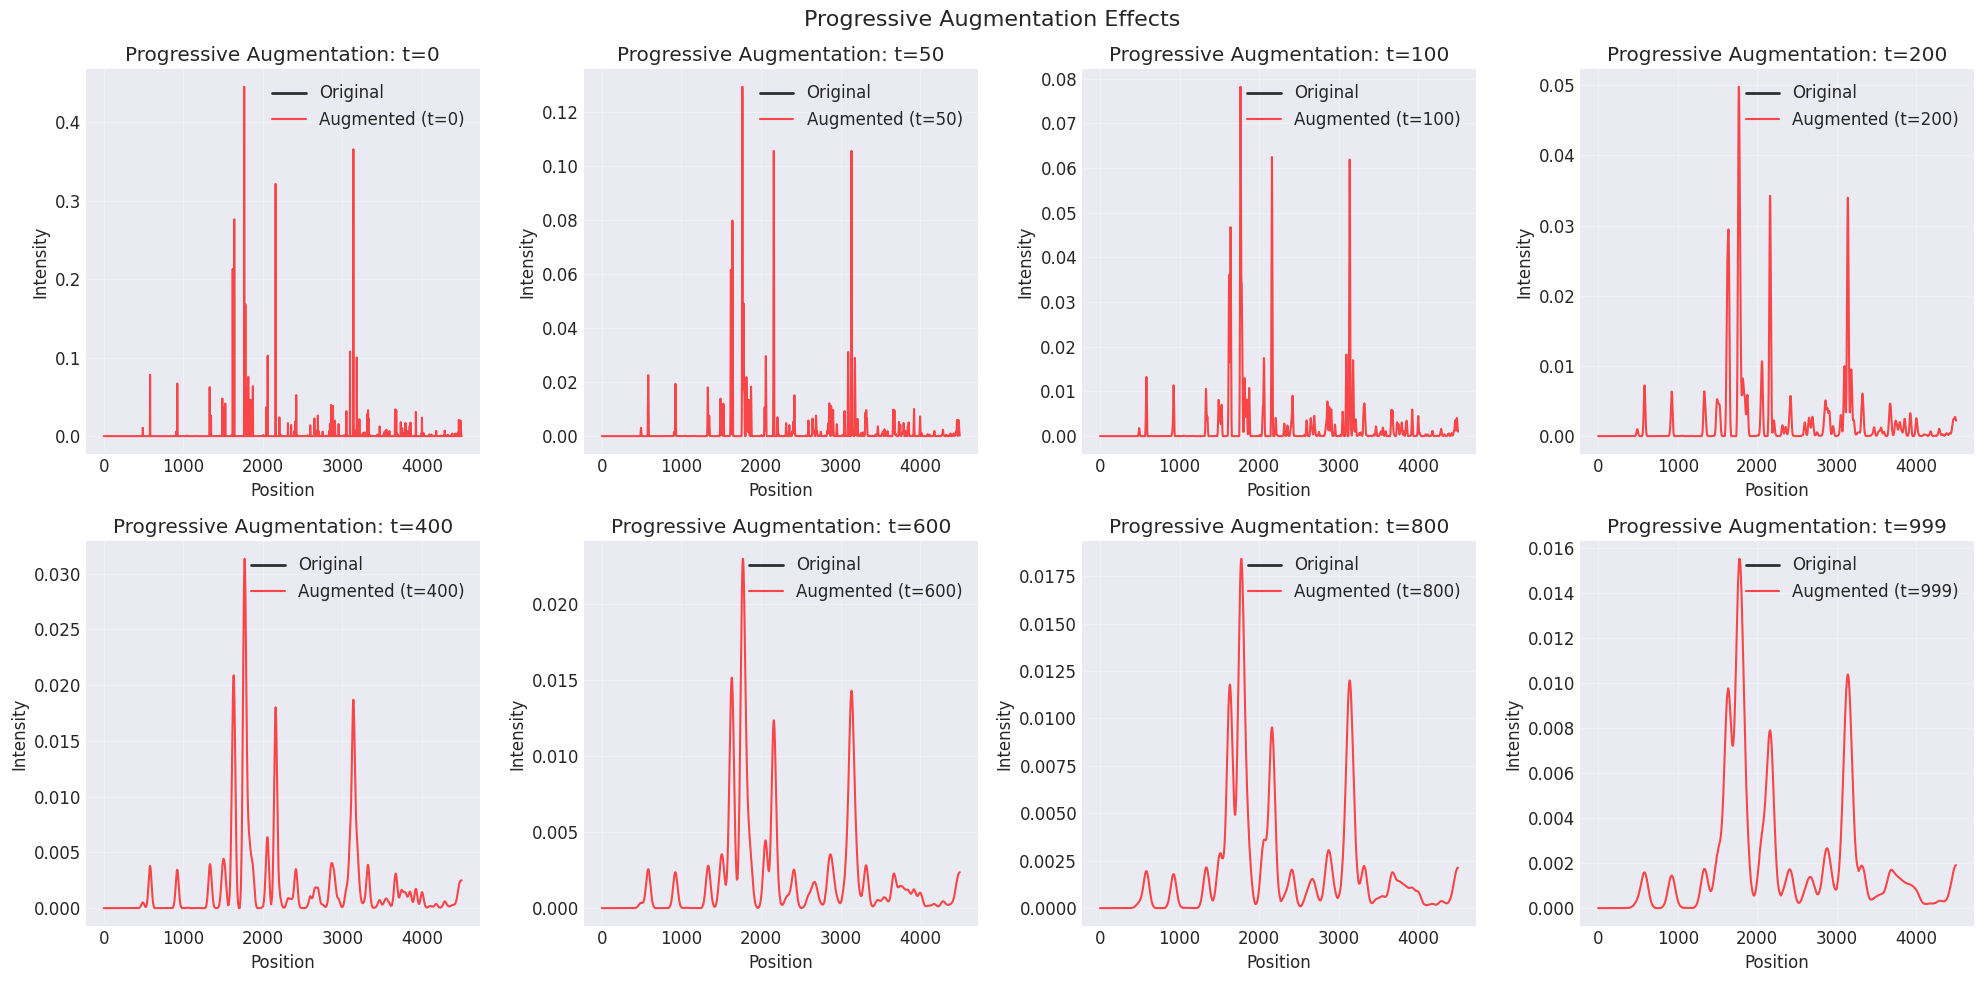

✓ Timestep effects analysis complete


In [22]:
# Individual timestep analysis
from validation.tests.timestep_effects import analyze_timestep_effects, test_progressive_augmentation
from validation.visualization.plotting import plot_timestep_analysis, plot_progressive_augmentation

# Analyze timestep effects
sample_idx = 0
timestep_results = analyze_timestep_effects(model, diffusion, test_synth[sample_idx], test_dtw[sample_idx])

# Plot results
fig = plot_timestep_analysis(timestep_results, test_synth[sample_idx], sample_idx)
plt.show()

# Test progressive augmentation
aug_patterns = test_progressive_augmentation(diffusion, test_synth[sample_idx])
fig = plot_progressive_augmentation(test_synth[sample_idx], aug_patterns)
plt.show()

print("✓ Timestep effects analysis complete")

### 7.3 DTW Conditioning Analysis

Testing DTW values: 100%|██████████| 11/11 [00:00<00:00, 74.43it/s]


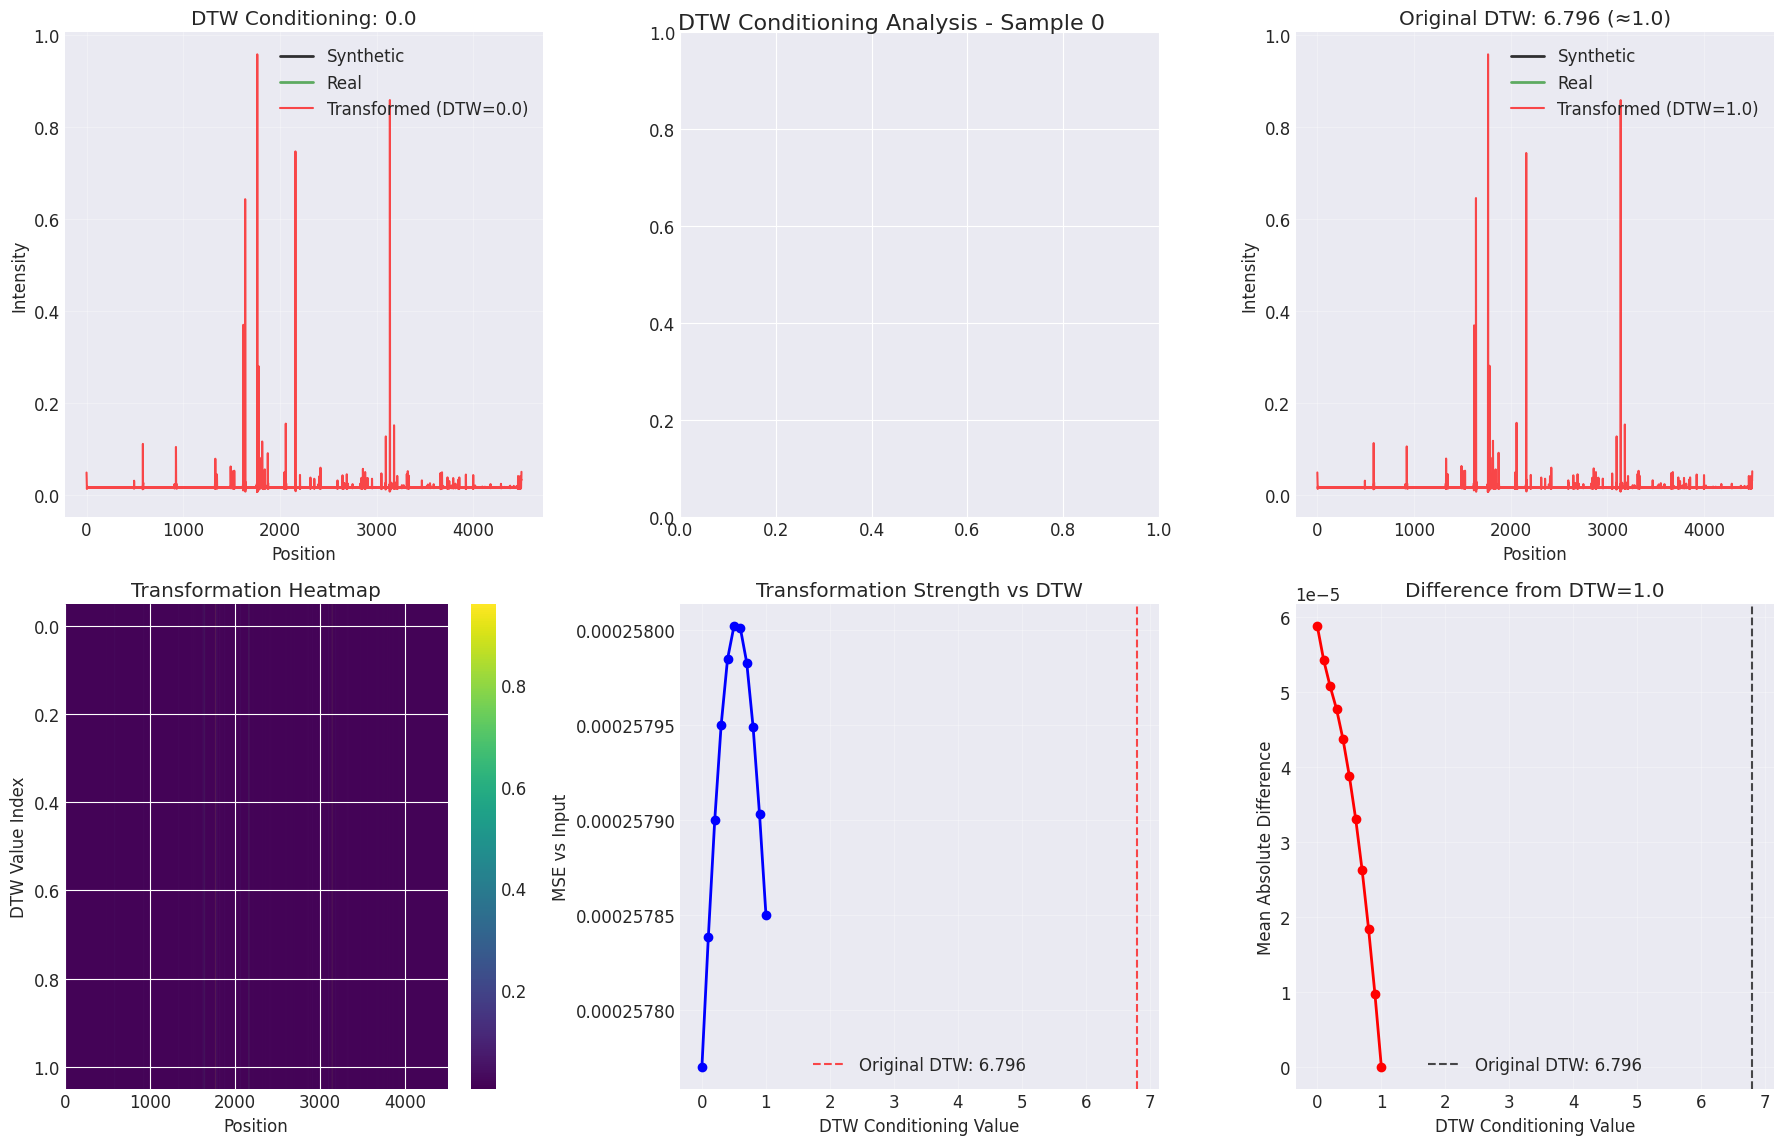

✓ DTW conditioning analysis complete


In [23]:
# Individual DTW conditioning test
from validation.tests.dtw_conditioning import analyze_dtw_conditioning
from validation.visualization.plotting import plot_dtw_analysis

# Analyze DTW conditioning
sample_idx = 0
test_real = data_splits['test']['real']

dtw_results = analyze_dtw_conditioning(model, test_synth[sample_idx])

# Plot results
fig = plot_dtw_analysis(dtw_results, test_synth[sample_idx], test_real[sample_idx], 
                       test_dtw[sample_idx].item(), sample_idx)
plt.show()

print("✓ DTW conditioning analysis complete")

## 8. Full Test Set Evaluation

Running full test set evaluation...


Evaluating test set: 100%|██████████| 63/63 [00:52<00:00,  1.20it/s]


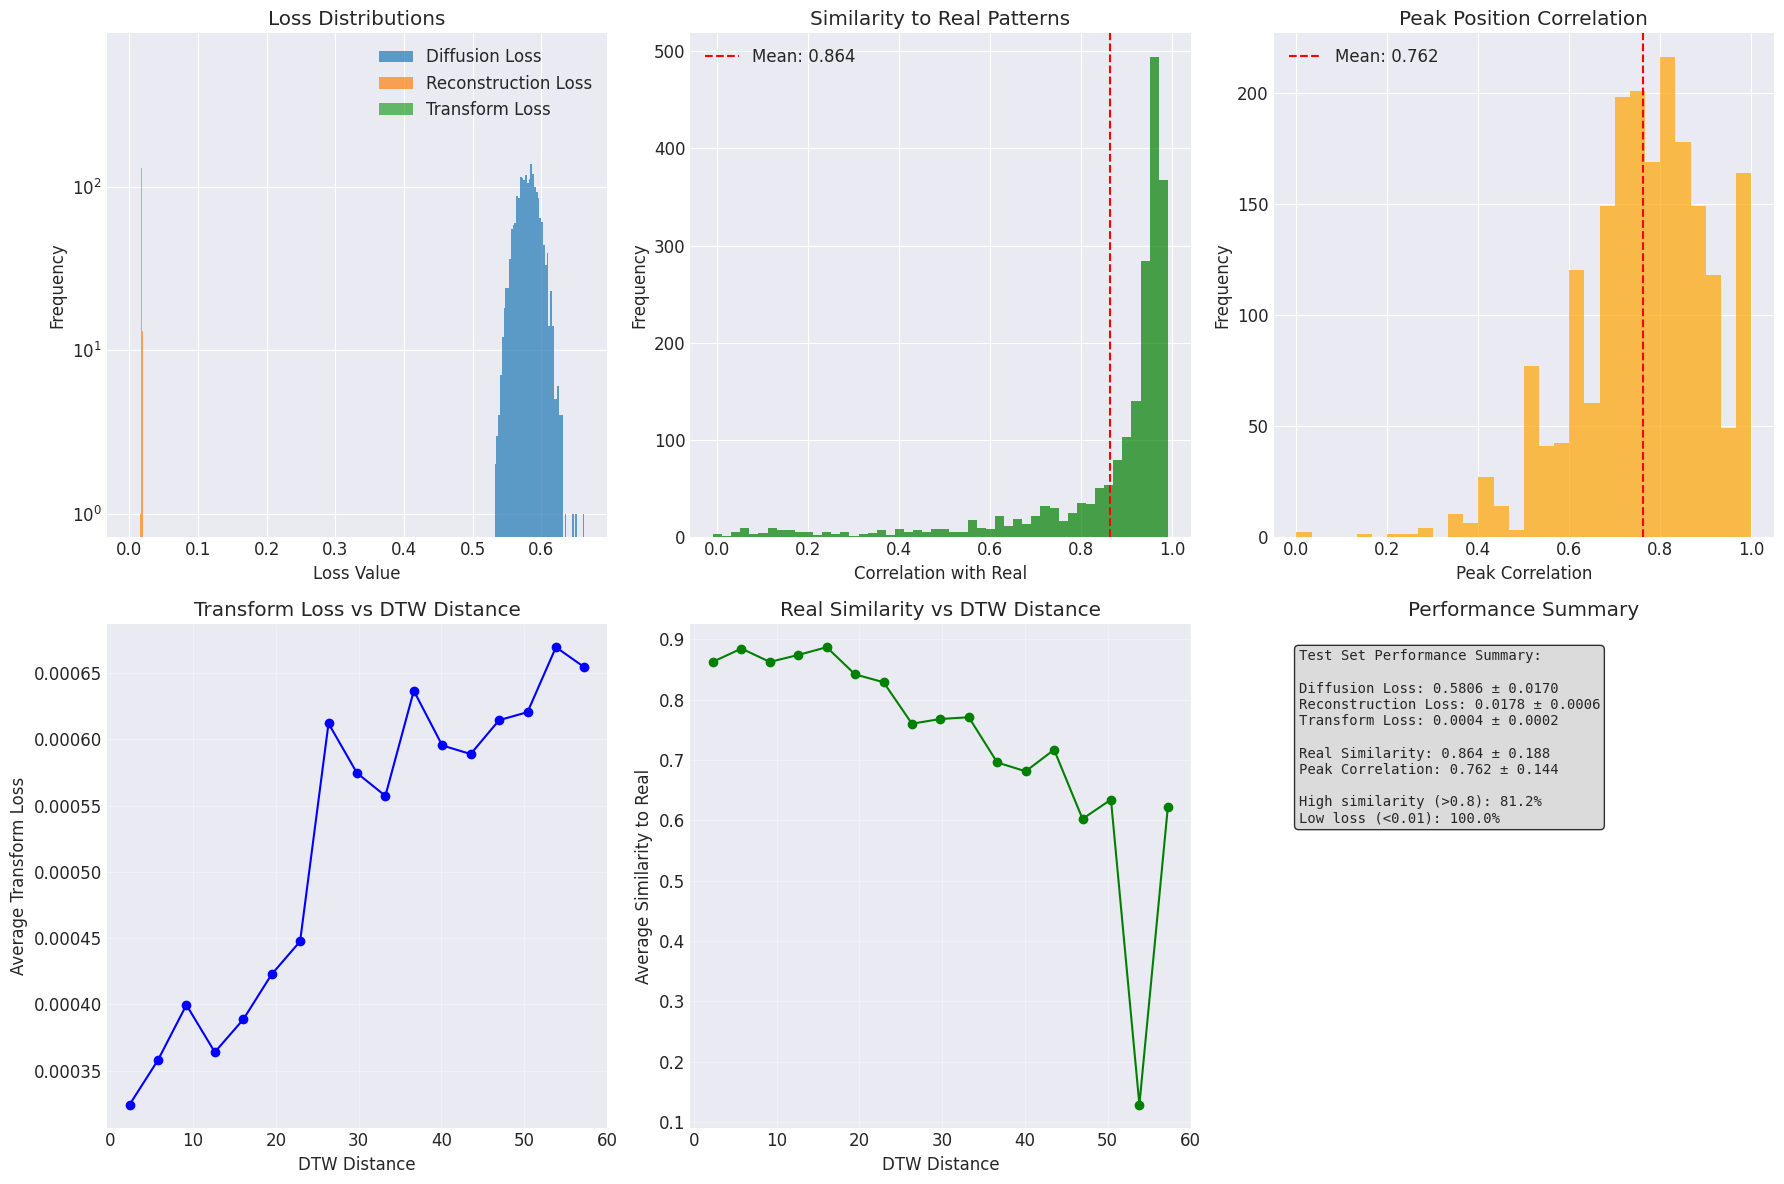

✓ Full test set evaluation complete


In [24]:
# Run full test set evaluation (may take longer)
from validation.analysis.validation_suite import evaluate_test_set_performance
from validation.visualization.plotting import plot_test_performance

print("Running full test set evaluation...")
full_test_results = evaluate_test_set_performance(
    model, diffusion, 
    data_splits['test']['synth'], 
    data_splits['test']['real'], 
    data_splits['test']['dtw'],
    batch_size=32
)

# Plot test performance
fig = plot_test_performance(full_test_results, data_splits['test']['dtw'])
plt.show()

print("✓ Full test set evaluation complete")

## 9. Interactive Exploration

Explore model behavior interactively:

In [25]:
# Create interactive explorer
from validation.visualization.interactive import create_interactive_explorer

print("Creating interactive model explorer...")
explorer = create_interactive_explorer(
    model, diffusion, 
    data_splits['test']['synth'][:20],  # Subset for faster interaction
    data_splits['test']['real'][:20], 
    data_splits['test']['dtw'][:20]
)

if explorer is not None:
    display(explorer)
    print("✓ Interactive explorer ready!")
    print("   Use the sliders and checkboxes above to explore model behavior")
else:
    print("⚠️  Interactive widgets not available in this environment")

Creating interactive model explorer...


✓ Interactive explorer ready!
   Use the sliders and checkboxes above to explore model behavior


## 10. Save Results

In [26]:
# Save validation results
from validation.analysis.validation_suite import save_validation_results

# Prepare metadata
model_info = {
    'total_parameters': sum(p.numel() for p in model.parameters()),
    'device': str(next(model.parameters()).device),
    'diffusion_timesteps': diffusion.num_timesteps
}

dataset_info = {
    'total_samples': len(data_splits['train']['synth']) + len(data_splits['val']['synth']) + len(data_splits['test']['synth']),
    'train_samples': len(data_splits['train']['synth']),
    'val_samples': len(data_splits['val']['synth']),
    'test_samples': len(data_splits['test']['synth']),
    'pattern_length': data_splits['test']['synth'].shape[-1],
    'dtw_range': [float(data_splits['test']['dtw'].min()), float(data_splits['test']['dtw'].max())]
}

# Save results
results_path = save_validation_results(
    validation_results,
    test_results=full_test_results if 'full_test_results' in locals() else None,
    model_info=model_info,
    dataset_info=dataset_info,
    output_path="xrd_diffusion_validation_results_modular.pkl"
)

print(f"✓ Results saved to: {results_path}")


💾 Validation results saved to: xrd_diffusion_validation_results_modular.pkl
✓ Results saved to: xrd_diffusion_validation_results_modular.pkl


## 11. Quick Summary

In [27]:
# Generate quick summary
from validation.analysis.report_generator import generate_quick_summary

quick_summary = generate_quick_summary(validation_results)
print(quick_summary)

XRD DIFFUSION MODEL - QUICK VALIDATION SUMMARY
Overall: 4/5 tests passed (80.0%)

Stochasticity  : ✅ PASS
Timestep Effects: ✅ PASS
DTW Conditioning: ❌ FAIL
Real Similarity: ✅ PASS
Model Stability: ✅ PASS

⚠️  1 issues need attention


## Summary

This modular validation notebook provides:

✅ **Easy-to-use interface** - Single command validation with `ValidationSuite`

✅ **Modular components** - Individual test modules for detailed analysis

✅ **Interactive exploration** - Real-time model behavior investigation

✅ **Comprehensive reporting** - Detailed validation reports and summaries

✅ **Debugging-friendly** - Separated concerns for easier troubleshooting

### Key Questions Answered:

1. **Is the model stochastic?** - Verified through deterministic vs stochastic mode testing
2. **How does timestep affect the model?** - Progressive augmentation analysis
3. **How does DTW distance change the model?** - Conditioning effectiveness validation
4. **Is augmentation similar to real-world data?** - Test set performance evaluation
5. **Does it work on the test set?** - Comprehensive generalization assessment

### Next Steps:

- Use the modular components in `validation/` for further analysis
- Extend individual test modules for specific research questions
- Create custom visualization scripts using the plotting utilities
- Integrate validation results into your training pipeline